In [1]:
from fastai.vision.all import *

In [2]:
CLASSES = ["good", "major_rust", "scratches", "total_rust"]

In [3]:
CHOSEN_PART = "metal_plate"

In [4]:
good_parts_train = sorted(os.listdir(f"{CHOSEN_PART}/train/good"))[0::1]
good_parts_test = sorted(os.listdir(f"{CHOSEN_PART}/test/good"))[0::1]
for i in range(len(good_parts_train)):
    good_parts_train[i] = f"{CHOSEN_PART}/train/good/{good_parts_train[i]}"
for i in range(len(good_parts_test)):
    good_parts_test[i] = f"{CHOSEN_PART}/test/good/{good_parts_test[i]}"
good_parts_ground_truth_train = ['good'] * len(good_parts_train)
good_parts_ground_truth_test = ['good'] * len(good_parts_test)

In [5]:
major_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[0:-4:]
major_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/major_rust"))[-4::]
for i in range(len(major_rust_train)):
    major_rust_train[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_train[i]}"
for i in range(len(major_rust_test)):
    major_rust_test[i] = f"{CHOSEN_PART}/test/major_rust/{major_rust_test[i]}"
major_rust_ground_truth_train = ['major_rust'] * len(major_rust_train)
major_rust_ground_truth_test = ['major_rust'] * len(major_rust_test)

In [6]:
scratches_train = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[0::2]
scratches_test = sorted(os.listdir(f"{CHOSEN_PART}/test/scratches"))[1::2]
for i in range(len(scratches_train)):
    scratches_train[i] = f"{CHOSEN_PART}/test/scratches/{scratches_train[i]}"
for i in range(len(scratches_test)):
    scratches_test[i] = f"{CHOSEN_PART}/test/scratches/{scratches_test[i]}"
scratches_ground_truth_train = ['scratches'] * len(scratches_train)
scratches_ground_truth_test = ['scratches'] * len(scratches_test)

In [7]:
total_rust_train = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[0:-4:]
total_rust_test = sorted(os.listdir(f"{CHOSEN_PART}/test/total_rust"))[-4::]
for i in range(len(total_rust_train)):
    total_rust_train[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_train[i]}"
for i in range(len(total_rust_test)):
    total_rust_test[i] = f"{CHOSEN_PART}/test/total_rust/{total_rust_test[i]}"
total_rust_ground_truth_train = ['total_rust'] * len(total_rust_train)
total_rust_ground_truth_test = ['total_rust'] * len(total_rust_test)

In [8]:
X_train = good_parts_train + major_rust_train + scratches_train + total_rust_train
X_test = good_parts_test + major_rust_test + scratches_test + total_rust_test
y_train = good_parts_ground_truth_train + major_rust_ground_truth_train + scratches_ground_truth_train + total_rust_ground_truth_train
y_test = good_parts_ground_truth_test + major_rust_ground_truth_test + scratches_ground_truth_test + total_rust_ground_truth_test

In [9]:
train_dls = ImageDataLoaders.from_lists(path='.', fnames=X_train+X_test, labels=y_train+y_test, batch_size=8, shuffle=True, valid_pct=0.2, item_tfms=Resize(512))

/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)
/usr/bin/nvidia-modprobe: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_ABI_DT_RELR' not found (required by /usr/bin/nvidia-modprobe)


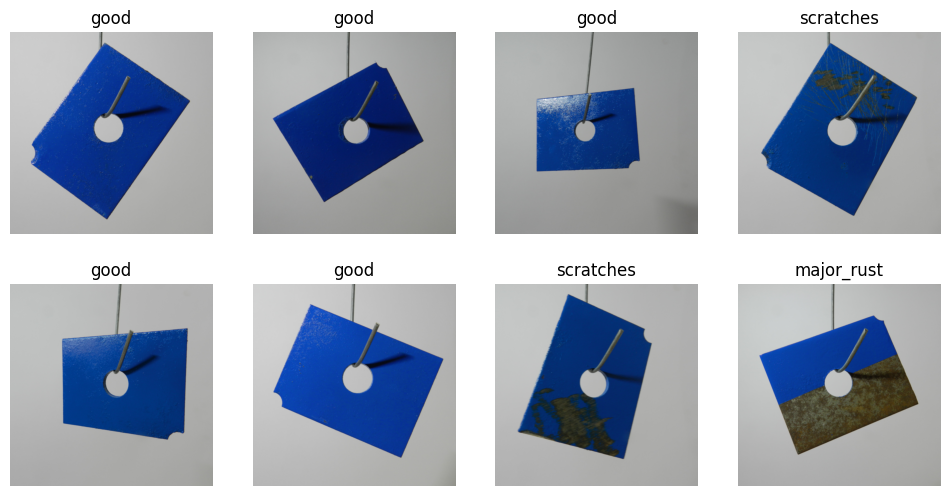

In [10]:
train_dls.show_batch()

In [11]:
EPOCHS = 10
opt_func = partial(Adam, lr=0.001)
classifier = vision_learner(train_dls, resnext50_32x4d, opt_func=opt_func, metrics=[error_rate, accuracy])

/home/tea/Documents/Tristar/.pytorch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tea/Documents/Tristar/.pytorch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
classifier.fine_tune(EPOCHS)

epoch,train_loss,valid_loss,error_rate,accuracy,time


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.300987,0.376387,0.133333,0.866667,00:04
1,0.409851,0.009032,0.000000,1.000000,00:04
2,0.285087,0.041145,0.033333,0.966667,00:04
3,0.214535,0.011681,0.000000,1.000000,00:04
4,0.191237,0.014943,0.000000,1.000000,00:04
5,0.236909,0.033342,0.033333,0.966667,00:04
6,0.211159,0.003575,0.000000,1.000000,00:04
7,0.187464,0.003613,0.000000,1.000000,00:04
8,0.164039,0.010476,0.000000,1.000000,00:04
9,0.129154,0.009330,0.000000,1.000000,00:04


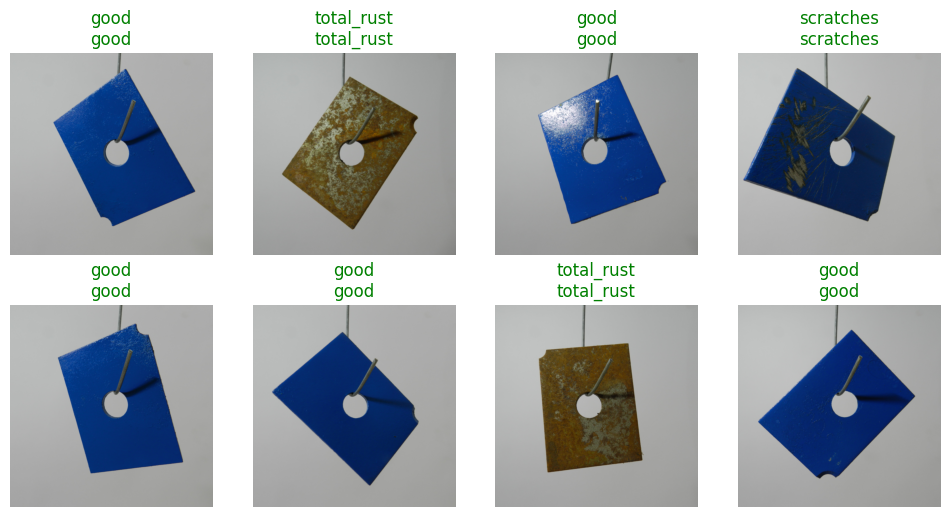

In [13]:
classifier.show_results()

In [14]:
classifier.export(f"{CHOSEN_PART}_classifier.pkl")